# QA 2 · La primera letra paso a paso contra Nielsen — por ciudad · sueros

**Pregunta:** si aplicamos **todo nuestro proceso de la Letra 1** (INEGI, NSE AMAI, Censo por manzana, clúster hexagonal y
AltScore) en la coordenada de cada tienda de la línea base de Nielsen de la ciudad (`qa/<carpeta>/Golden Stores Sueros … .xlsx`:
`qa/Bepensa/` = ZM Mérida, autoservicios de la Región Sur; `qa/Guadalajara/` = ZM Guadalajara, farmacias de cadena nacional),
¿cuánto le atinamos a **su primera letra**? Y ¿qué paso del proceso nos acerca o nos aleja?

**Alcance:** las tiendas de la línea base que caen en la **ZM** (Mérida 65, Guadalajara 178), que es donde tenemos todos los insumos
(hogares por hexágono, NSE AMAI por AGEB, Censo por manzana y AltScore). Solo la **primera letra** (NSE): la segunda (venta) está en el QA 1.

**Cómo se lee:** la sección 1 arma, para cada tienda, cada insumo del proceso; la 2 mide cada paso contra Nielsen (AUC: ¿ordena
igual?; exactitud y κ: ¿da la misma letra?) con cuatro cortes; la 3 prueba el peso de AltScore y el radio; la 4 da la exactitud
del proceso tal como lo usa hoy el 06 y la del mejor proceso; la 5 escribe el **Excel ejecutivo** con QA 1 + QA 2.

**Reproducir:** `uv run python qa/correr_qa.py <ciudad>` (corre QA 1 → QA 2 → consistencia interna; antes el pipeline 00 → 06).

In [1]:
import os
import sys
import hashlib
from pathlib import Path

os.environ.setdefault("CIUDAD", "merida")
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(BASE / "src"))

import numpy as np
import pandas as pd
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score
from shapely.geometry import Point
from IPython.display import display

import config as C
import altscore as A
import eda
import letras as LT
import rappi as R
from descargas import descargar_fuente, extraer

eda.estilo()
pd.set_option("display.width", 220, "display.max_columns", 40, "display.float_format", "{:,.3f}".format)
# carpeta de cada ciudad en qa/ (igual que el QA 1) y región de la sección 4b: Mérida = todo el archivo (Región Sur, 15 estados);
# Guadalajara = el área Nielsen de la ZM (el archivo es nacional: 5,676 farmacias)
QA_CIUDADES = {
    "merida": dict(carpeta="Bepensa", linea_base="Golden Stores Sueros R.Sur - KO FY'23.xlsx", canal="Autoservicios",
                   filtro=("Zonas Metropolitanas", "MERIDA"), region=None, region_txt="Región Sur"),
    "guadalajara": dict(carpeta="Guadalajara", linea_base="Golden Stores Sueros Pharma Nacional - KO FY'23.xlsx", canal="Farmacias de cadena",
                        filtro=("Región Nielsen", "Area III OESTE CENTRO Guadalajara"), region="Area III OESTE CENTRO Guadalajara",
                        region_txt="área Nielsen Oeste Centro Guadalajara"),
}
QC = QA_CIUDADES[C.CIUDAD]
QA = BASE / "qa" / QC["carpeta"]
OUT = QA / "salidas"
OUT.mkdir(exist_ok=True)
F_NIELSEN = QA / QC["linea_base"]
CANAL, REGION_TXT = QC["canal"], QC["region_txt"]
F_LETRAS = C.PROC / f"letras_pdv_{C.CLIENTE}_{C.SLUG}.parquet"
F_HEX = C.PROC / f"hexagonos_h3r{C.H3_RES}_{C.CLIENTE}_{C.SLUG}.gpkg"
F_AGEB = C.PROC / f"ageb_{C.SLUG}.gpkg"
F_MZ = C.PROC / f"manzanas_{C.SLUG}.gpkg"
F_ALT = C.PROC / f"altscore_{C.CLIENTE}_{C.SLUG}.parquet"
for f_ in [F_NIELSEN, F_LETRAS, F_HEX, F_AGEB, F_MZ, F_ALT]:
    assert f_.exists(), f"Falta {f_.relative_to(BASE)}: correr el pipeline 00 → 06"
R300, RES_CL, LAM, MIN_ALT = C.RADIO_PDV_M, C.NSE_CLUSTER_RES, C.ALTSCORE_PESO_NSE, C.ALTSCORE_MIN_PUNTOS
NSE = ["A/B", "C+", "C", "C-", "D+", "D/E"]
K_NSE = pd.Series({"A/B": 6, "C+": 5, "C": 4, "C-": 3, "D+": 2, "D/E": 1})
RNG = np.random.default_rng(eda.SEMILLA)


def boot(fn, *arrs, B=500):
    """IC95 por bootstrap de tiendas (semilla fija)."""
    n, vals = len(arrs[0]), []
    for _ in range(B):
        i = RNG.integers(0, n, n)
        try:
            vals.append(fn(*[np.asarray(a)[i] for a in arrs]))
        except ValueError:
            continue
    return np.nanpercentile(vals, [2.5, 97.5])


def lectura_k(k):
    return str(pd.cut([k], [-1, 0.2, 0.4, 0.6, 0.8, 1.01], labels=["pobre", "regular", "moderado", "bueno", "casi perfecto"])[0])


def medir(paso, variable, corte, ref, x, umbral):
    """Una fila: exactitud y κ (con IC95) de la letra H si x ≥ umbral (umbral escalar o serie por tienda) contra Nielsen."""
    ok = pd.notna(x)
    r_, x_ = np.asarray(ref)[ok], np.asarray(x, float)[ok]
    u_ = np.asarray(umbral, float)[ok] if np.ndim(umbral) else umbral
    p_ = np.where(x_ >= u_, "H", "L")
    acc = (r_ == p_).mean()
    k = eda.kappa_cohen(pd.Series(r_), pd.Series(p_))
    lo_k, hi_k = boot(lambda a, b: eda.kappa_cohen(pd.Series(a), pd.Series(b)), r_, p_)
    lo_a, hi_a = boot(lambda a, b: (a == b).mean(), r_, p_)
    return {"paso": paso, "variable": variable, "corte": corte, "n": int(ok.sum()), "exactitud": acc, "IC95 exactitud": f"[{lo_a:.2f}, {hi_a:.2f}]",
            "κ de Cohen": k, "IC95 κ": f"[{lo_k:.2f}, {hi_k:.2f}]", "lectura κ": lectura_k(k), "% H nuestro": (p_ == "H").mean() * 100,
            "% H Nielsen": (r_ == "H").mean() * 100}


print(f"{C.ZM_NOMBRE} · radio {R300} m · clúster NSE H3 res {RES_CL} · AltScore λ = {LAM:g} (≥ {MIN_ALT} puntos)")

ZM Guadalajara · radio 300 m · clúster NSE H3 res 9 · AltScore λ = 0.25 (≥ 5 puntos)


## 0. La línea base y su regla de la primera letra

**Qué se hace:** se leen las tiendas Nielsen de la ZM con su clúster y su perfil NSE (los % de A/B … D/E del área que
reporta Nielsen). De ahí se calcula su nivel NSE N = Σ k·p_k (1 = D/E … 6 = A/B) y se despeja la referencia fija de su índice
(ref = % / índice × 100). Es el **techo**: con su propio perfil y su referencia, ¿cuánto se reproducen sus letras?

**Por qué:** si la regla de Nielsen es "NSE del área contra una referencia regional", nuestro mejor resultado posible es
reproducir su perfil NSE y usar un corte equivalente; lo que falte de ahí es error de insumos (sección 2) o de corte.

In [2]:
raw = pd.read_excel(F_NIELSEN, sheet_name=0, header=None)
h1, h2 = raw.iloc[7].ffill(), raw.iloc[8]
cols = [f"{' '.join(str(a).split())}|{b}" if pd.notna(a) and b in ("HHs", "%", "Indice") else str(b).strip() for a, b in zip(h1, h2)]
nie = raw.iloc[9:].copy()
nie.columns = cols
nie = nie[nie["Nielsen ID"].notna()].reset_index(drop=True)
nie = nie.rename(columns={c: "Cluster" for c in nie.columns if c.strip() == "Cluster"})
nie["Cadena"] = nie[next(c for c in nie.columns if c.startswith("Cadena de"))]
for c in NSE:
    for s_ in ("%", "Indice"):
        nie[f"{c}|{s_}"] = pd.to_numeric(nie[f"{c}|{s_}"], errors="coerce")
pn_all = nie[[f"{c}|%" for c in NSE]].set_axis(NSE, axis=1)
REF_N = (pn_all / nie[[f"{c}|Indice" for c in NSE]].set_axis(NSE, axis=1) * 100).median()
REF_N = REF_N / REF_N.sum()
N_REF = float((REF_N * K_NSE).sum())
AUC_NSE = roc_auc_score(nie["Cluster"].astype(str).str.strip().str[0] == "H", (pn_all * K_NSE).sum(axis=1) / pn_all.sum(axis=1))
zm = nie[nie[QC["filtro"][0]].astype(str).str.strip().eq(QC["filtro"][1])].reset_index(drop=True)
zm["lat"], zm["lon"] = zm.Latitud.astype(float), zm.Longitud.astype(float)
zm["cluster_n"] = zm["Cluster"].astype(str).str.strip()
zm["L1n"] = zm.cluster_n.str[0]
zm["cadena"] = zm["Cadena"].astype(str).str.strip()
pz = zm[[f"{c}|%" for c in NSE]].set_axis(NSE, axis=1)
zm["N_nielsen"] = (pz * K_NSE).sum(axis=1) / pz.sum(axis=1)
techo = medir("0 · Techo", "N de Nielsen (su propio perfil)", f"su referencia regional (N ≥ {N_REF:.2f})", zm.L1n, zm.N_nielsen, N_REF)
AUC_NSE_ZM = roc_auc_score(zm.L1n == "H", zm.N_nielsen)              # en la ZM (en Guadalajara va al revés: H = NSE bajo)
print(f"{len(zm)} tiendas Nielsen ({CANAL}) en la {C.ZM_NOMBRE} · Nielsen H {(zm.L1n == 'H').mean():.0%} · referencia regional de su índice: "
      + ", ".join(f"{c} {v * 100:.1f}%" for c, v in REF_N.items()) + f" (N = {N_REF:.2f})")
print(f"Techo: con su propio perfil y su referencia, sus letras se reproducen en {techo['exactitud']:.0%} (κ {techo['κ de Cohen']:.2f}). "
      f"En toda la línea base su nivel NSE separa sus H de sus L con AUC {AUC_NSE:.2f}" + ("" if AUC_NSE >= 0.75 else ": su 1.ª letra no es de NSE."))
display(zm.groupby("cadena").agg(tiendas=("L1n", "size"), **{"% H Nielsen": ("L1n", lambda s: (s == "H").mean() * 100)}).round(0))

178 tiendas Nielsen (Farmacias de cadena) en la ZM Guadalajara · Nielsen H 71% · referencia regional de su índice: A/B 13.9%, C+ 16.9%, C 16.5%, C- 16.2%, D+ 12.9%, D/E 23.7% (N = 3.32)
Techo: con su propio perfil y su referencia, sus letras se reproducen en 58% (κ -0.16). En toda la línea base su nivel NSE separa sus H de sus L con AUC 0.49: su 1.ª letra no es de NSE.


,tiendas,% H Nielsen
cadena,,
FARMACIAS - BENAVIDES,89,67.000
FARMACIAS - DEL AHORRO,63,83.000
FARMACIAS - FARMACON,22,59.000
FARMACIAS - FARMAPRONTO,2,0.000
FARMACIAS - FARMATODO,2,50.000


## 1. Nuestro proceso en la coordenada de cada tienda Nielsen

**Qué se hace:** para cada tienda se calcula cada insumo del proceso, en el orden en que la Letra 1 los usa:

| Paso | Insumo | De dónde sale |
|---|---|---|
| 1 | NSE del **punto** (hexágono H3 res 10 de la tienda) | hogares AMAI por hexágono del 04 |
| 2 | NSE de su **AGEB** | microsimulación AMAI del 01 |
| 3 | **Índice del Censo** por manzana (auto, computadora, internet, escolaridad) en 300 m del centro del clúster | Censo 2020, manzanas del 01 |
| 4 | **Clúster NSE**: hexágono H3 res 9 + buffer de 300 m desde su centro (N INEGI) — la Letra 1 del 06 sin AltScore | 04 + regla del 06 |
| 5 | **AltScore** del clúster (índice NSE digital 0-100, puntos a ≤ 300 m del centro) | 00b |
| 6 | Clúster **con AltScore**: N* = (1 − λ)·N + λ·Ñ (λ = 0.25) — la Letra 1 final del 06 | 06 |
| 7 | **% ABC+** del clúster (A/B + C+) y buffer de la **propia tienda** (sin clúster) | 04 |

**Por qué:** así se ve en qué paso se gana o se pierde exactitud, no solo el resultado final.

In [3]:
hexg = gpd.read_file(F_HEX).set_index("hex")
hx = hexg[[f"HHs_{c}" for c in NSE]].set_axis(NSE, axis=1)
ageb = gpd.read_file(F_AGEB)
mzg = gpd.read_file(F_MZ)
let = pd.read_parquet(F_LETRAS)
ob = let[let.objetivo]

# paso 1 · punto (hexágono res 10)
zm["hex10"] = [h3.latlng_to_cell(a, b, C.H3_RES) for a, b in zip(zm.lat, zm.lon)]
zm["N_punto"] = LT.nivel_medio(hx.reindex(zm.hex10).reset_index(drop=True)).to_numpy()
# paso 2 · AGEB
pts = gpd.GeoDataFrame(zm[["Nielsen ID"]], geometry=gpd.points_from_xy(zm.lon, zm.lat), crs=4326).to_crs(ageb.crs)
j_ = gpd.sjoin(pts, ageb[["CVEGEO", *[f"HHs_{c}" for c in NSE], "geometry"]], how="left", predicate="within")
j_ = j_[~j_.index.duplicated()]
zm["AGEB"] = j_.CVEGEO.reindex(zm.index).to_numpy()
zm["N_ageb"] = LT.nivel_medio(j_[[f"HHs_{c}" for c in NSE]].set_axis(NSE, axis=1).reindex(zm.index)).to_numpy()
# paso 4 · clúster NSE (hexágono res 9 + 300 m desde su centro)
zm["cl"] = [h3.latlng_to_cell(a, b, RES_CL) for a, b in zip(zm.lat, zm.lon)]
cla, clo = LT.centros(zm.cl)
hh_cl = LT.suma_area(hx, LT.hexagonos_en_radio(cla, clo, R300, C.H3_RES)).set_axis(NSE, axis=1)
zm["N_cluster"] = LT.nivel_medio(hh_cl).to_numpy()
zm["abc_cluster"] = ((hh_cl["A/B"] + hh_cl["C+"]) / hh_cl.sum(axis=1).replace(0, np.nan) * 100).to_numpy()
zm["hog_cluster"] = hh_cl.sum(axis=1).to_numpy()
for c in NSE:
    zm[f"pct_{c}"] = (100 * hh_cl[c] / hh_cl.sum(axis=1).replace(0, np.nan)).to_numpy()
# paso 7b · buffer de la propia tienda (sin clúster)
hh_pr = LT.suma_area(hx, LT.hexagonos_en_radio(zm.lat, zm.lon, R300, C.H3_RES)).set_axis(NSE, axis=1)
zm["N_buffer_tienda"] = LT.nivel_medio(hh_pr).to_numpy()

# paso 3 · índice del Censo por manzana (mismo método que el 06: rangos normalizados → PC1 → percentil 0-100)
descargar_fuente(C.FUENTES["ageb"])
D_AGEB = extraer(C.ARCHIVOS["ageb"])
f_censo = next(D_AGEB.rglob("conjunto_de_datos_ageb_urbana_*_cpv2020.csv"))
COLS_CENSO = ["ENTIDAD", "MUN", "LOC", "AGEB", "MZA", "VIVPARH_CV", "VPH_AUTOM", "VPH_PC", "VPH_INTER", "GRAPROES"]
try:
    cz = pd.read_csv(f_censo, dtype=str, usecols=COLS_CENSO, encoding="utf-8-sig")
except UnicodeDecodeError:
    cz = pd.read_csv(f_censo, dtype=str, usecols=COLS_CENSO, encoding="latin-1")
cz = cz[(cz.MZA != "000") & cz.MUN.isin(C.ZM_MUNICIPIOS)].copy()
cz["CVEGEO"] = cz.ENTIDAD.str.zfill(2) + cz.MUN + cz.LOC + cz.AGEB + cz.MZA
v = cz[COLS_CENSO[5:]].apply(pd.to_numeric, errors="coerce")
viv = v.VIVPARH_CV.where(v.VIVPARH_CV > 0)
IND = pd.DataFrame({"auto": v.VPH_AUTOM / viv * 100, "pc": v.VPH_PC / viv * 100, "internet": v.VPH_INTER / viv * 100, "escolaridad": v.GRAPROES})
IND.iloc[:, :3] = IND.iloc[:, :3].clip(upper=100)
Zm = np.column_stack([A.rango_normal(IND[c]) for c in IND])
comp = ~np.isnan(Zm).any(axis=1)
_, vec_ = np.linalg.eigh(np.corrcoef(Zm[comp], rowvar=False))
w_ = vec_[:, -1] * np.sign(vec_[:, -1].sum())
cz["indice_censo"] = np.nan
cz.loc[comp, "indice_censo"] = stats.rankdata((Zm @ w_)[comp]) / comp.sum() * 100
mzc = mzg[["CVEGEO", "hog", "geometry"]].merge(cz[["CVEGEO", "indice_censo"]], on="CVEGEO", how="left")
mzc["area"] = mzc.area
centros = gpd.GeoSeries(gpd.points_from_xy(clo, cla), crs=4326).to_crs(mzc.crs)
indc = []
for g_ in centros.buffer(R300):
    sub = mzc[mzc.intersects(g_)]
    w = sub.hog * sub.intersection(g_).area / sub.area
    ok = sub.indice_censo.notna() & (w > 0)
    indc.append(float((sub.indice_censo[ok] * w[ok]).sum() / w[ok].sum()) if ok.any() else np.nan)
zm["censo_cluster"] = indc

# pasos 5 y 6 · AltScore (misma escala que el 06: cuantiles de los clústeres con PDV objetivo)
alt = pd.read_parquet(F_ALT)
loc = A.ubicacion(alt)
alt = alt.dropna(subset=[loc["lat"], loc["lon"]]).reset_index(drop=True)
va = alt.indice_nse_altscore.to_numpy(float)
cer = R.en_radio(cla, clo, alt[loc["lat"]].to_numpy(float), alt[loc["lon"]].to_numpy(float), R300)
zm["alt_cluster"] = [np.nanmean(va[i]) if len(i) and np.isfinite(va[i]).any() else np.nan for i in cer]
zm["alt_puntos"] = [int(np.isfinite(va[i]).sum()) for i in cer]
base_cl = ob.drop_duplicates("cluster_nse")
zm["N_alt"] = LT.a_escala(zm.alt_cluster.where(zm.alt_puntos >= MIN_ALT), base_cl.N_inegi, x_base=base_cl.alt_cluster).to_numpy()


def n_star(lam):
    return LT.mover_nse(zm.N_cluster, zm.N_alt, lam).to_numpy()


zm["N_cluster_alt"] = n_star(LAM)
insumos = zm[["Nielsen ID", "Store Name", "cadena", "Municipio", "cluster_n", "L1n", "N_nielsen", "N_punto", "N_ageb", "censo_cluster",
              "N_cluster", "alt_cluster", "alt_puntos", "N_alt", "N_cluster_alt", "abc_cluster", "N_buffer_tienda", "hog_cluster"]]
display(insumos.head(10).round(2))
corr_ = insumos[["N_nielsen", "N_punto", "N_ageb", "censo_cluster", "N_cluster", "alt_cluster", "N_cluster_alt", "abc_cluster", "N_buffer_tienda"]].corr("spearman")
display(corr_.round(2))

[ok] ya existe ageb_mza_urbana_14_cpv2020_csv.zip


,Nielsen ID,Store Name,cadena,Municipio,cluster_n,L1n,N_nielsen,N_punto,N_ageb,censo_cluster,N_cluster,alt_cluster,alt_puntos,N_alt,N_cluster_alt,abc_cluster,N_buffer_tienda,hog_cluster
0,2005076-0,BENAVIDES AMERICAS - 2005076X0,FARMACIAS - BENAVIDES,Guadalajara (JAL),HH,H,3.990,4.500,4.340,83.930,4.370,65.890,5,3.360,4.120,53.020,4.290,357.360
1,2005579-0,BENAVIDES AMERICAS 3 - 2005579X0,FARMACIAS - BENAVIDES,Guadalajara (JAL),HH,H,4.040,4.330,4.430,88.250,3.960,50.800,3,NaN,3.960,44.630,4.360,292.710
2,2005780-0,BENAVIDES CHAPULTEPEC - 2005780X0,FARMACIAS - BENAVIDES,Guadalajara (JAL),HH,H,4.030,4.130,4.130,85.990,4.290,42.620,7,2.940,3.950,50.530,4.270,209.910
3,2005245-0,BENAVIDES INDEPENDENCIA - 2005245X0,FARMACIAS - BENAVIDES,Guadalajara (JAL),HH,H,3.230,3.250,3.250,48.990,3.320,91.910,22,4.430,3.600,28.350,3.550,604.750
4,2005825-0,BENAVIDES JARDIN REAL - 2005825X0,FARMACIAS - BENAVIDES,Zapopan (JAL),HH,H,4.860,3.630,5.020,82.730,3.830,79.310,5,3.800,3.820,47.220,3.740,480.390
5,2005527-0,BENAVIDES JARDINES DE LA CRUZ - 2005527X0,FARMACIAS - BENAVIDES,Guadalajara (JAL),HH,H,3.980,4.170,4.170,72.910,4.130,21.070,15,2.470,3.710,46.330,4.100,989.360
6,2005733-0,BENAVIDES JARDINES DEL VALLE - 2005733X0,FARMACIAS - BENAVIDES,Zapopan (JAL),HH,H,3.980,4.120,4.130,78.270,4.200,91.560,20,4.400,4.250,49.420,4.190,"1,291.700"
7,2005560-0,BENAVIDES LA NORMAL - 2005560X0,FARMACIAS - BENAVIDES,Guadalajara (JAL),HH,H,3.570,3.580,3.580,63.580,3.670,62.050,17,3.300,3.580,36.380,3.620,767.260
8,2005652-0,BENAVIDES OBLATOS - 2005652X0,FARMACIAS - BENAVIDES,Guadalajara (JAL),HH,H,3.070,3.570,3.570,52.110,3.220,15.780,36,2.280,2.990,27.790,3.400,"1,091.060"
9,2005506-0,BENAVIDES PEDRO MORENO - 2005506X0,FARMACIAS - BENAVIDES,Guadalajara (JAL),HH,H,3.370,3.360,3.280,61.610,3.420,13.470,14,2.230,3.120,28.270,3.500,222.470


,N_nielsen,N_punto,N_ageb,censo_cluster,N_cluster,alt_cluster,N_cluster_alt,abc_cluster,N_buffer_tienda
N_nielsen,1.000,0.760,0.770,0.810,0.800,0.510,0.790,0.830,0.780
N_punto,0.760,1.000,0.910,0.860,0.910,0.470,0.890,0.920,0.910
N_ageb,0.770,0.910,1.000,0.840,0.850,0.410,0.830,0.860,0.880
censo_cluster,0.810,0.860,0.840,1.000,0.940,0.480,0.920,0.950,0.920
N_cluster,0.800,0.910,0.850,0.940,1.000,0.490,0.970,0.990,0.960
alt_cluster,0.510,0.470,0.410,0.480,0.490,1.000,0.610,0.520,0.440
N_cluster_alt,0.790,0.890,0.830,0.920,0.970,0.610,1.000,0.970,0.930
abc_cluster,0.830,0.920,0.860,0.950,0.990,0.520,0.970,1.000,0.950
N_buffer_tienda,0.780,0.910,0.880,0.920,0.960,0.440,0.930,0.950,1.000


## 2. Cada paso contra la primera letra de Nielsen

**Qué se hace:** para cada insumo: (a) **AUC** = probabilidad de que una tienda H de Nielsen tenga un valor mayor que una L (1 =
ordena perfecto, 0.5 = azar), con IC95 por bootstrap; (b) la letra con **cuatro cortes**, igual que se pidió:

| Corte | Qué es | Para qué variables |
|---|---|---|
| relativo | la media de las tiendas Nielsen de la ZM | todas |
| por cadena | la media de su cadena (el análogo del **subcanal** con que compara el 06) | todas |
| del 06 | la media de nuestros **PDV Tradicional objetivo** (el corte que usa hoy la Letra 1) | escala N (1-6) |
| referencia Nielsen | N de la referencia fija de su índice (Mérida N ≥ 3.01) | escala N (1-6) |

**Por qué:** el AUC dice si el insumo **ordena** las zonas como Nielsen sin depender del corte; la exactitud dice si con ese corte
sale la **misma letra**. Separar ambas cosas dice si lo que hay que cambiar es el insumo o el corte.

,paso,AUC,IC95 AUC,n,ρ con el N de Nielsen
0,1 · NSE del punto (hexágono res 10),0.196,"[0.12, 0.28]",175,0.761
1,2 · NSE de su AGEB,0.211,"[0.13, 0.30]",175,0.771
2,4 · Clúster NSE (INEGI),0.165,"[0.10, 0.24]",177,0.798
3,6 · Clúster NSE + AltScore (Letra 1 del 06),0.159,"[0.10, 0.24]",177,0.792
4,7b · Buffer de la propia tienda,0.180,"[0.11, 0.26]",177,0.782
5,3 · Índice del Censo por manzana (clúster),0.215,"[0.13, 0.29]",177,0.812
6,5 · AltScore solo (clúster),0.325,"[0.23, 0.41]",174,0.512
7,7 · % ABC+ del clúster,0.173,"[0.10, 0.26]",177,0.825


,paso,variable,corte,n,exactitud,IC95 exactitud,κ de Cohen,IC95 κ,lectura κ,% H nuestro,% H Nielsen
0,1 · NSE del punto (hexágono res 10),N_punto,relativo (media de las 178),175,0.354,"[0.29, 0.43]",-0.394,"[-0.50, -0.27]",pobre,58.857,70.857
1,1 · NSE del punto (hexágono res 10),N_punto,por cadena (análogo del subcanal),175,0.349,"[0.28, 0.42]",-0.400,"[-0.51, -0.28]",pobre,58.286,70.857
2,1 · NSE del punto (hexágono res 10),N_punto,del 06 (media de nuestros PDV Tradicional),175,0.669,"[0.61, 0.74]",-0.043,"[-0.12, 0.05]",pobre,93.714,70.857
3,1 · NSE del punto (hexágono res 10),N_punto,referencia Nielsen (N ≥ 3.32),175,0.611,"[0.54, 0.68]",-0.107,"[-0.20, 0.02]",pobre,85.714,70.857
4,2 · NSE de su AGEB,N_ageb,relativo (media de las 178),175,0.389,"[0.32, 0.46]",-0.348,"[-0.46, -0.23]",pobre,61.143,70.857
5,2 · NSE de su AGEB,N_ageb,por cadena (análogo del subcanal),175,0.366,"[0.30, 0.43]",-0.370,"[-0.49, -0.25]",pobre,58.857,70.857
6,2 · NSE de su AGEB,N_ageb,del 06 (media de nuestros PDV Tradicional),175,0.657,"[0.58, 0.73]",-0.048,"[-0.15, 0.07]",pobre,91.429,70.857
7,2 · NSE de su AGEB,N_ageb,referencia Nielsen (N ≥ 3.32),175,0.594,"[0.51, 0.66]",-0.148,"[-0.24, -0.03]",pobre,85.143,70.857
8,4 · Clúster NSE (INEGI),N_cluster,relativo (media de las 178),177,0.333,"[0.27, 0.40]",-0.416,"[-0.51, -0.30]",pobre,57.062,70.621
9,4 · Clúster NSE (INEGI),N_cluster,por cadena (análogo del subcanal),177,0.333,"[0.27, 0.40]",-0.416,"[-0.52, -0.30]",pobre,57.062,70.621


Todos los insumos NSE ordenan las zonas al revés que Nielsen (sus H están en zonas de NSE más bajo) (AUC de 0.16 a 0.32); el más alto es 5 · AltScore solo (clúster) (AUC 0.32 [0.23, 0.41]). AltScore solo: AUC 0.32. La exactitud depende sobre todo del corte (tabla de pasos).


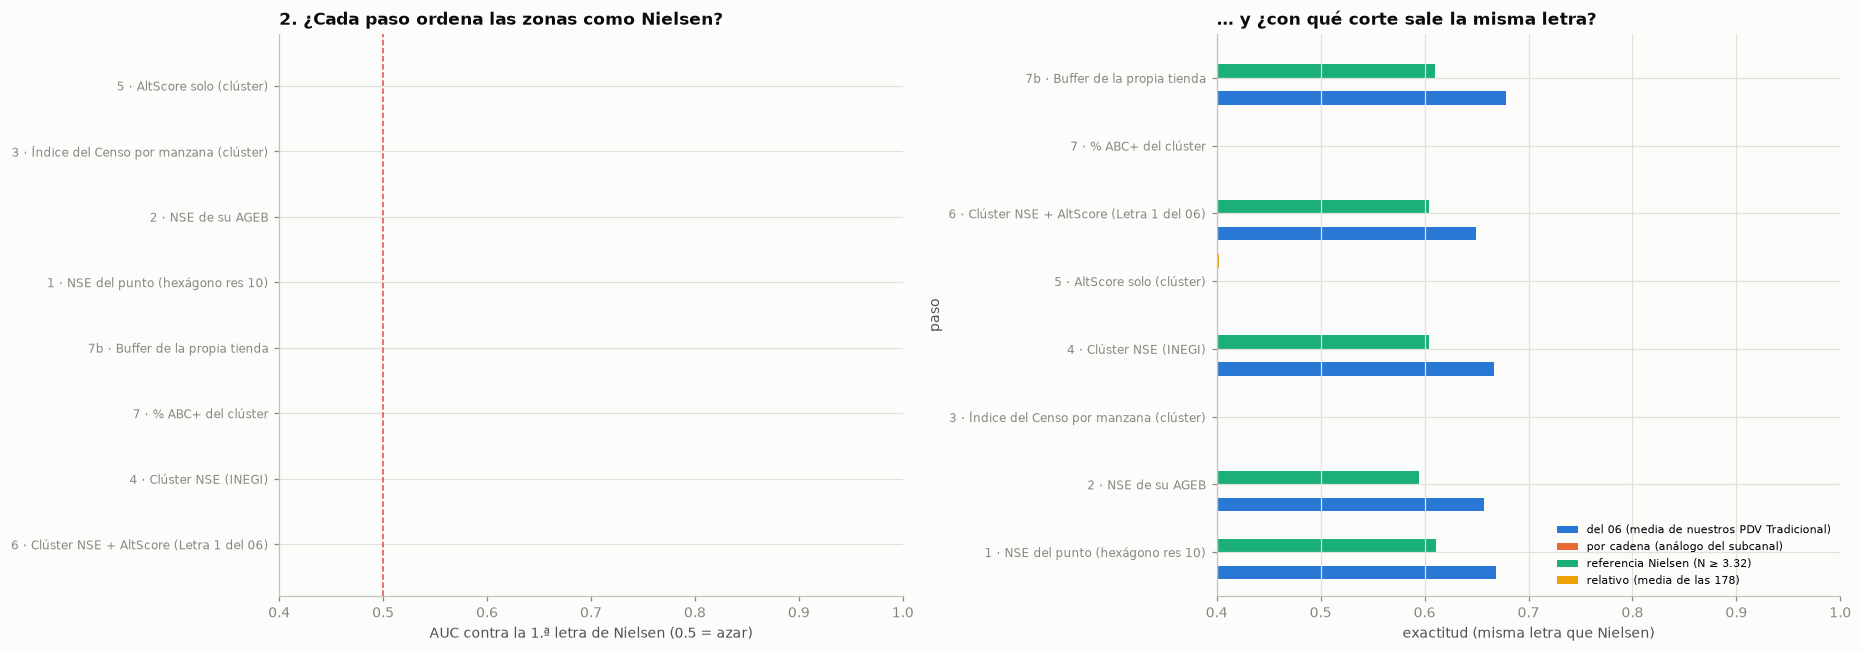

In [4]:
media_cadena = lambda col: zm.groupby("cadena")[col].transform("mean")
ESCALA_N = {"1 · NSE del punto (hexágono res 10)": "N_punto", "2 · NSE de su AGEB": "N_ageb", "4 · Clúster NSE (INEGI)": "N_cluster",
            "6 · Clúster NSE + AltScore (Letra 1 del 06)": "N_cluster_alt", "7b · Buffer de la propia tienda": "N_buffer_tienda"}
OTRAS = {"3 · Índice del Censo por manzana (clúster)": "censo_cluster", "5 · AltScore solo (clúster)": "alt_cluster",
         "7 · % ABC+ del clúster": "abc_cluster"}
CORTE_06 = {"N_punto": ob.N_punto.mean(), "N_ageb": ob.N_ageb.mean(), "N_cluster": ob.N_inegi.mean(), "N_cluster_alt": ob.N.mean(),
            "N_buffer_tienda": ob.N_pdv.mean()}
pasos, auc = [], []
for nombre, col in {**ESCALA_N, **OTRAS}.items():
    x_ = zm[col]
    ok = x_.notna()
    a_ = roc_auc_score(zm.L1n[ok] == "H", x_[ok])
    lo_, hi_ = boot(lambda y, x: roc_auc_score(y, x), (zm.L1n[ok] == "H").to_numpy(), x_[ok].to_numpy())
    auc.append({"paso": nombre, "AUC": a_, "IC95 AUC": f"[{lo_:.2f}, {hi_:.2f}]", "n": int(ok.sum()),
                "ρ con el N de Nielsen": stats.spearmanr(x_[ok], zm.N_nielsen[ok])[0]})
    pasos.append(medir(nombre, col, f"relativo (media de las {len(zm)})", zm.L1n, x_, x_.mean()))
    pasos.append(medir(nombre, col, "por cadena (análogo del subcanal)", zm.L1n, x_, media_cadena(col)))
    if col in ESCALA_N.values():
        pasos.append(medir(nombre, col, "del 06 (media de nuestros PDV Tradicional)", zm.L1n, x_, CORTE_06[col]))
        pasos.append(medir(nombre, col, f"referencia Nielsen (N ≥ {N_REF:.2f})", zm.L1n, x_, N_REF))
auc = pd.DataFrame(auc)
pasos = pd.DataFrame(pasos)
display(auc.round(3))
display(pasos.round(3))
mejor_auc = auc.loc[auc.AUC.idxmax()]
PASOS = (("Todos los insumos NSE ordenan las zonas como Nielsen" if auc.AUC.min() >= 0.75 else "Todos los insumos NSE ordenan las zonas al revés que Nielsen (sus H están en zonas de NSE más bajo)" if auc.AUC.max() < 0.5 else "Los insumos NSE ordenan las zonas de Nielsen con AUC")
         + f" (AUC de {auc.AUC.min():.2f} a {auc.AUC.max():.2f}); el más alto es "
         f"{mejor_auc.paso} (AUC {mejor_auc.AUC:.2f} {mejor_auc['IC95 AUC']}). AltScore solo: AUC "
         f"{auc.set_index('paso').loc['5 · AltScore solo (clúster)', 'AUC']:.2f}. La exactitud depende sobre todo del corte (tabla de pasos).")
print(PASOS)

fig, ax = plt.subplots(1, 2, figsize=(17, 6))
aa = auc.sort_values("AUC")
ax[0].barh(aa.paso, aa.AUC, color=[eda.PALETA[0] if "06" in p_ else eda.MUTED for p_ in aa.paso])
ax[0].axvline(0.5, color=eda.PALETA[7], ls="--", lw=1)
ax[0].set(xlim=(0.4, 1.0), xlabel="AUC contra la 1.ª letra de Nielsen (0.5 = azar)", title="2. ¿Cada paso ordena las zonas como Nielsen?")
ax[0].tick_params(axis="y", labelsize=8)
pv = pasos.pivot_table(index="paso", columns="corte", values="exactitud")
pv.plot.barh(ax=ax[1], width=0.8)
ax[1].set(xlabel="exactitud (misma letra que Nielsen)", title="… y ¿con qué corte sale la misma letra?", xlim=(0.4, 1.0))
ax[1].legend(fontsize=7, loc="lower right")
ax[1].tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

## 3. Sensibilidad: peso de AltScore (λ) y radio del buffer

**Qué se hace:** se repite el paso 6 con λ de 0 a 1 y el paso 4 con buffers de 200 m a 1.5 km desde el centro del clúster, con el
corte relativo y el del 06.

**Por qué:** λ = 0.25 y 300 m son decisiones nuestras; si otro valor acerca mucho más a Nielsen, es evidencia para cambiarlo.

In [5]:
sens = []
for lam in [0, 0.1, 0.25, 0.5, 0.75, 1.0]:
    x_ = pd.Series(n_star(lam))
    corte_06_lam = float(LT.mover_nse(ob.N_inegi, ob.N_alt, lam).mean())      # media de nuestros PDV con ese mismo λ
    for corte, u_ in [("relativo", x_.mean()), ("del 06", corte_06_lam)]:
        f_ = medir("λ AltScore", f"λ = {lam:g}", corte, zm.L1n, x_, u_)
        f_["AUC"] = roc_auc_score(zm.L1n.to_numpy()[x_.notna().to_numpy()] == "H", x_.dropna())
        sens.append(f_)
for r_ in [200, 300, 400, 600, 800, 1000, 1500]:
    hh_r = LT.suma_area(hx, LT.hexagonos_en_radio(cla, clo, r_, C.H3_RES)).set_axis(NSE, axis=1)
    x_ = LT.nivel_medio(hh_r)
    f_ = medir("radio del clúster", f"{r_} m", "relativo", zm.L1n, x_, x_.mean())
    f_["AUC"] = roc_auc_score(zm.L1n.to_numpy()[x_.notna().to_numpy()] == "H", x_.dropna())
    sens.append(f_)
sens = pd.DataFrame(sens)
display(sens[["paso", "variable", "corte", "exactitud", "κ de Cohen", "IC95 κ", "AUC", "% H nuestro"]].round(3))
SENS = ("λ de AltScore: " + " · ".join(f"{r.variable} {r.exactitud:.0%}" for r in sens[sens.paso.eq("λ AltScore") & sens.corte.eq("relativo")].itertuples())
        + " (corte relativo). Radio: " + " · ".join(f"{r.variable} {r.exactitud:.0%}" for r in sens[sens.paso.eq("radio del clúster")].itertuples()) + ".")
print(SENS)

,paso,variable,corte,exactitud,κ de Cohen,IC95 κ,AUC,% H nuestro
0,λ AltScore,λ = 0,relativo,0.333,-0.416,"[-0.52, -0.29]",0.165,57.062
1,λ AltScore,λ = 0,del 06,0.667,-0.044,"[-0.13, 0.04]",0.165,93.785
2,λ AltScore,λ = 0.1,relativo,0.339,-0.397,"[-0.51, -0.27]",0.158,56.497
3,λ AltScore,λ = 0.1,del 06,0.661,-0.054,"[-0.14, 0.04]",0.158,93.220
4,λ AltScore,λ = 0.25,relativo,0.294,-0.450,"[-0.56, -0.32]",0.159,53.107
5,λ AltScore,λ = 0.25,del 06,0.650,-0.073,"[-0.16, 0.03]",0.159,92.090
6,λ AltScore,λ = 0.5,relativo,0.282,-0.432,"[-0.56, -0.31]",0.166,49.718
7,λ AltScore,λ = 0.5,del 06,0.633,-0.117,"[-0.18, -0.03]",0.166,91.525
8,λ AltScore,λ = 0.75,relativo,0.294,-0.371,"[-0.49, -0.25]",0.177,46.328
9,λ AltScore,λ = 0.75,del 06,0.599,-0.170,"[-0.25, -0.08]",0.177,88.136


λ de AltScore: λ = 0 33% · λ = 0.1 34% · λ = 0.25 29% · λ = 0.5 28% · λ = 0.75 29% · λ = 1 32% (corte relativo). Radio: 200 m 36% · 300 m 33% · 400 m 33% · 600 m 34% · 800 m 34% · 1000 m 34% · 1500 m 33%.


## 4. Exactitud final de la primera letra

**Qué se hace:** tres números: (1) **el proceso tal como lo usa hoy el 06** (clúster NSE + AltScore λ = 0.25, corte = media de
nuestros PDV Tradicional); (2) **el mismo proceso con el mejor corte** sin usar información de Nielsen (relativo o por cadena);
(3) el **techo** (su propio perfil con su referencia). Más la matriz de confusión del proceso del 06.

**Por qué:** es la respuesta directa para el tomador de decisiones: hoy acertamos X; con un cambio de corte acertaríamos Y; lo
máximo alcanzable con esta regla es Z.

In [6]:
p06 = pasos[pasos.variable.eq("N_cluster_alt") & pasos.corte.str.startswith("del 06")].iloc[0]
cand = pasos[pasos.variable.isin(["N_cluster", "N_cluster_alt"]) & pasos.corte.str.startswith(("relativo", "por cadena"))]
pmejor = cand.loc[cand.exactitud.idxmax()]
final_l1 = pd.DataFrame([
    {"proceso": "Hoy (06): clúster NSE + AltScore, corte de nuestros PDV", **{k: p06[k] for k in ["n", "exactitud", "IC95 exactitud", "κ de Cohen", "IC95 κ", "lectura κ", "% H nuestro", "% H Nielsen"]}},
    {"proceso": f"Mejor corte: {pmejor.paso.split('· ')[1]} · {pmejor.corte}", **{k: pmejor[k] for k in ["n", "exactitud", "IC95 exactitud", "κ de Cohen", "IC95 κ", "lectura κ", "% H nuestro", "% H Nielsen"]}},
    {"proceso": "Techo: perfil y referencia de Nielsen", **{k: techo[k] for k in ["n", "exactitud", "IC95 exactitud", "κ de Cohen", "IC95 κ", "lectura κ", "% H nuestro", "% H Nielsen"]}},
])
final_l1["azar"] = float(((zm.L1n.value_counts(normalize=True)) ** 2).sum())
display(final_l1.round(3))
let06 = np.where(zm.N_cluster_alt >= CORTE_06["N_cluster_alt"], "H", "L")
display(pd.crosstab(zm.L1n.rename("Nielsen"), pd.Series(let06, name="nuestra (06)"), margins=True))
FINAL_L1 = (f"Primera letra: hoy (proceso del 06) acertamos {p06.exactitud:.0%} (κ {p06['κ de Cohen']:.2f} {p06['IC95 κ']}); con el mejor corte "
            f"({pmejor.corte}) {pmejor.exactitud:.0%} (κ {pmejor['κ de Cohen']:.2f}); el techo con la regla de Nielsen es {techo['exactitud']:.0%}. "
            f"El corte del 06 marca H el {p06['% H nuestro']:.0f}% de las zonas contra {p06['% H Nielsen']:.0f}% de Nielsen: ahí está la diferencia.")
print(FINAL_L1)

,proceso,n,exactitud,IC95 exactitud,κ de Cohen,IC95 κ,lectura κ,% H nuestro,% H Nielsen,azar
0,"Hoy (06): clúster NSE + AltScore, corte de nue...",177,0.650,"[0.58, 0.71]",-0.073,"[-0.15, 0.03]",pobre,92.090,70.621,0.586
1,Mejor corte: Clúster NSE (INEGI) · relativo (m...,177,0.333,"[0.27, 0.40]",-0.416,"[-0.51, -0.30]",pobre,57.062,70.621,0.586
2,Techo: perfil y referencia de Nielsen,178,0.579,"[0.51, 0.65]",-0.156,"[-0.26, -0.05]",pobre,82.584,70.787,0.586


nuestra (06),H,L,All
Nielsen,,,
H,113,13,126
L,50,2,52
All,163,15,178


Primera letra: hoy (proceso del 06) acertamos 65% (κ -0.07 [-0.15, 0.03]); con el mejor corte (relativo (media de las 178)) 33% (κ -0.42); el techo con la regla de Nielsen es 58%. El corte del 06 marca H el 92% de las zonas contra 71% de Nielsen: ahí está la diferencia.


## 4b. Toda la región de la línea base: la primera letra de cada tienda

**Qué se hace:** el mismo proceso de la Letra 1 en la coordenada de cada tienda de la región (Mérida: las 1,420 tiendas de la Región
Sur; Guadalajara: las 178 farmacias del área Nielsen Oeste Centro Guadalajara, todas en la ZM). Las tiendas de la ZM usan el 04 de la
ciudad (sección 1); fuera de la ZM, los insumos del notebook 01 corrido por estado (`qasur_<ENT>`: los 15 estados de la Región Sur,
todos sus municipios; ver `qa/preparar_estados.py`). Igual que el 04: cada manzana lleva el
NSE de su AGEB en proporción a sus hogares, se suman las localidades rurales, se actualiza a 2025 con el crecimiento municipal
de la Intercensal y se reparte **por área** en hexágonos H3 res 10; el clúster es el hexágono H3 res 9 de la tienda + los
hexágonos res 10 con centro a ≤ 300 m de su centro. Solo se arman los hexágonos alrededor de las tiendas.
**Validación:** en las tiendas de la ZM este cálculo por estado debe dar el mismo nivel NSE que el del 04 (sección 1), si el estado
está procesado. AltScore solo existe en la ZM: fuera de ella la letra va solo con INEGI (λ = 0) y el corte "como hoy" es la media INEGI
de nuestros PDV (mismo corte del 06 sin AltScore).

**Por qué:** para tener nuestra estimación en todas y cada una de las tiendas de la región, no solo en la ZM.

In [7]:
from shapely.geometry import Polygon

ENT_DE = {v: k for k, v in C.ESTADOS.items()} | {"Veracruz de Ignacio de la Llave": "30", "Coahuila de Zaragoza": "05",
                                                  "Michoacán de Ocampo": "16"}
if QC["region"]:
    nie = nie[nie["Región Nielsen"].astype(str).str.strip().eq(QC["region"])].reset_index(drop=True)
nie["ENT"] = nie.Estado.astype(str).str.strip().map(ENT_DE)
assert nie.ENT.notna().all(), f"estado sin clave: {nie.loc[nie.ENT.isna(), 'Estado'].unique()}"
nie["lat"], nie["lon"] = pd.to_numeric(nie.Latitud, errors="coerce"), pd.to_numeric(nie.Longitud, errors="coerce")
nie["cl"] = [h3.latlng_to_cell(a, b, RES_CL) for a, b in zip(nie.lat, nie.lon)]
HHC = [f"HHs_{c}" for c in NSE]


def nse_region(ent, filas):
    """N del clúster (H3 res 9 + 300 m) para las tiendas `filas` del estado `ent`, con el método del 04 y los insumos del 01."""
    P = BASE / "data" / "processed" / f"qasur_{ent}"
    slug = f"zm_qasur_{ent}"
    if not (P / f"manzanas_{slug}.gpkg").exists():
        return pd.DataFrame(index=filas.index, columns=["N_region", "hog_region", *[f"pct_{c}" for c in NSE]], dtype=float), "falta el 01 del estado"
    ag = pd.read_parquet(P / f"nse_ageb_{slug}.parquet")
    la_, lo_ = LT.centros(filas.cl)
    celdas = sorted({h for v in LT.hexagonos_en_radio(la_, lo_, R300, C.H3_RES) for h in v})
    mzr = gpd.read_file(P / f"manzanas_{slug}.gpkg")
    rej = gpd.GeoDataFrame({"hex": celdas}, crs=4326, geometry=[Polygon([(b, a) for a, b in h3.cell_to_boundary(c)]) for c in celdas]).to_crs(mzr.crs)
    caja = rej.total_bounds
    mzr = mzr.cx[caja[0]:caja[2], caja[1]:caja[3]]
    mzr = mzr.merge(ag[["CVEGEO", *HHC]], left_on="CVEGEO_AGEB", right_on="CVEGEO", suffixes=("", "_a"))
    mzr[HHC] = mzr[HHC].values * mzr.share.values[:, None]
    mzr = mzr[mzr[HHC[0]].notna() & (mzr.hog > 0)]
    mzr["MUN"] = mzr.CVEGEO.str[2:5]
    rur = gpd.read_file(P / f"rurales_{slug}.gpkg").to_crs(mzr.crs).cx[caja[0]:caja[2], caja[1]:caja[3]]
    piezas = gpd.GeoDataFrame(pd.concat([mzr[["MUN", *HHC, "geometry"]], rur[["MUN", *HHC, "geometry"]]], ignore_index=True), crs=mzr.crs)
    f_crec = P / f"crecimiento_municipal_{slug}.parquet"
    if f_crec.exists():
        crec = pd.read_parquet(f_crec)
        piezas[HHC] = piezas[HHC].values * piezas.MUN.map(crec.factor_hogares).fillna(1.0).values[:, None]
    piezas["area_p"] = piezas.geometry.area
    ped = gpd.overlay(piezas[["area_p", *HHC, "geometry"]], rej, how="intersection", keep_geom_type=True)
    ped[HHC] = ped[HHC].values * (ped.geometry.area / ped.area_p).values[:, None]
    hexr = ped.groupby("hex")[HHC].sum().set_axis(NSE, axis=1)
    hh_ = LT.suma_area(hexr, LT.hexagonos_en_radio(la_, lo_, R300, C.H3_RES)).set_axis(NSE, axis=1)
    tot = hh_.sum(axis=1)
    out = pd.DataFrame({"N_region": LT.nivel_medio(hh_).to_numpy(), "hog_region": tot.to_numpy()}, index=filas.index)
    for c in NSE:
        out[f"pct_{c}"] = (100 * hh_[c] / tot.where(tot > 0)).to_numpy()
    return out, "ok"


COLS_REG = ["N_region", "hog_region", *[f"pct_{c}" for c in NSE]]
nie[COLS_REG], estado_ok = np.nan, {}
for ent, filas in nie.groupby("ENT"):
    n_, st_ = nse_region(ent, filas)
    nie.loc[filas.index, COLS_REG] = n_[COLS_REG].to_numpy(dtype=float)
    estado_ok[ent] = st_
print("Estados:", ", ".join(f"{e} {v}" for e, v in estado_ok.items()))
# validación en la ZM: cálculo por estado vs el del 04 (sección 1), si el estado de la ZM está procesado
val = zm[["Nielsen ID", "N_cluster"]].merge(nie[["Nielsen ID", "N_region"]], on="Nielsen ID").dropna()
RHO_VAL = stats.spearmanr(val.N_cluster, val.N_region)[0] if len(val) > 2 else np.nan
DIF_VAL = (val.N_cluster - val.N_region).abs().median() if len(val) else np.nan
VALIDACION = (f"En las {len(val)} tiendas de la {C.ZM_NOMBRE} el cálculo por estado da el mismo nivel NSE que el del notebook 04 (ρ = {RHO_VAL:.2f})."
              if len(val) > 2 else f"No aplica: las tiendas de la {C.ZM_NOMBRE} usan directo el 04 de la ciudad (su estado no se procesó aparte).")
print(VALIDACION)
# en la ZM, hogares y % por nivel del clúster salen del 04 (sección 1)
_zi = zm.set_index("Nielsen ID")
for c_ in COLS_REG:
    src_ = {"N_region": "N_cluster", "hog_region": "hog_cluster"}.get(c_, c_)
    nie[c_] = nie[c_].fillna(nie["Nielsen ID"].map(_zi[src_]))
# letra "como hoy": en la ZM, la del 04 con AltScore; fuera, INEGI con el corte INEGI de nuestros PDV
nie["N_est"] = nie["Nielsen ID"].map(zm.set_index("Nielsen ID").N_cluster_alt).fillna(nie.N_region)
en_zm = nie["Nielsen ID"].isin(zm["Nielsen ID"])
corte_hoy = np.where(en_zm, CORTE_06["N_cluster_alt"], CORTE_06["N_cluster"])
nie["L1_hoy"] = np.where(nie.N_est.isna(), None, np.where(nie.N_est >= corte_hoy, "H", "L"))
nie["L1_rel"] = np.where(nie.N_est.isna(), None, np.where(nie.N_est >= nie.N_est.mean(), "H", "L"))
nie["L1n"] = nie["Cluster"].astype(str).str.strip().str[0]
okr = nie.N_est.notna()
reg_hoy = medir(f"4b · {REGION_TXT}", "N_est", "como hoy (corte del 06)", nie.L1n[okr], nie.N_est[okr], corte_hoy[okr.to_numpy()])
reg_rel = medir(f"4b · {REGION_TXT}", "N_est", "relativo (media de las tiendas)", nie.L1n[okr], nie.N_est[okr], nie.N_est[okr].mean())
reg_ref = medir(f"4b · {REGION_TXT}", "N_est", f"referencia Nielsen (N ≥ {N_REF:.2f})", nie.L1n[okr], nie.N_est[okr], N_REF)
region = pd.DataFrame([reg_hoy, reg_rel, reg_ref])
nie["L1_ref"] = np.where(nie.N_est.isna(), None, np.where(nie.N_est >= N_REF, "H", "L"))
_e = nie.assign(est=okr, ok_hoy=lambda t: (t.L1_hoy == t.L1n).where(okr), ok_rel=lambda t: (t.L1_rel == t.L1n).where(okr),
                ok_ref=lambda t: (t.L1_ref == t.L1n).where(okr), H_n=lambda t: (t.L1n == "H").astype(float),
                H_o=lambda t: (t.L1_hoy == "H").astype(float).where(okr))
por_estado = _e.groupby("Estado").agg(**{"tiendas Nielsen": ("L1n", "size"), "con nuestra estimación": ("est", "sum"),
                                         "nivel NSE medio (1-6)": ("N_est", "mean"), "% H Nielsen": ("H_n", "mean"),
                                         "% H nuestro (como hoy)": ("H_o", "mean"), "% acierto como hoy": ("ok_hoy", "mean"),
                                         "% acierto corte relativo": ("ok_rel", "mean"), "% acierto referencia Nielsen": ("ok_ref", "mean")})
pct_cols = [c for c in por_estado if c.startswith("%")]
por_estado[pct_cols] *= 100
display(region.round(3))
display(por_estado.round(0))
# lo mismo por municipio (toda la región) + las comparaciones del QA 1 en los municipios de la ZM
_e["Municipio_"] = _e.Municipio.astype(str).str.replace(r"\s*\(.*\)\s*$", "", regex=True).str.strip()
por_municipio = _e.groupby(["Estado", "Municipio_"]).agg(**{"tiendas Nielsen": ("L1n", "size"), "con nuestra estimación": ("est", "sum"),
                                                          "% H Nielsen": ("H_n", "mean"), "% H nuestro (como hoy)": ("H_o", "mean"),
                                                          "% acierto 1.ª letra como hoy": ("ok_hoy", "mean"),
                                                          "% acierto 1.ª letra corte relativo": ("ok_rel", "mean"),
                                                          "% acierto 1.ª letra referencia Nielsen": ("ok_ref", "mean")})
pct_mun = [c for c in por_municipio if c.startswith("%")]
por_municipio[pct_mun] *= 100
_ac = pd.read_parquet(OUT / "qa1_aciertos_tienda.parquet")
_ac_cols = [c for c in _ac if c not in ("Nielsen ID", "Municipio")]
_ac_m = (_ac.groupby("Municipio")[_ac_cols].mean() * 100).rename(columns=lambda c: f"% acierto QA 1 · {c}")
por_municipio = por_municipio.reset_index().rename(columns={"Municipio_": "Municipio"}).merge(_ac_m.reset_index(), on="Municipio", how="left")
pct_mun = [c for c in por_municipio if c.startswith("%")]
por_municipio = por_municipio.sort_values(["Estado", "tiendas Nielsen"], ascending=[True, False])
display(por_municipio.round(0).head(20))
REGION = (f"{REGION_TXT} ({int(okr.sum()):,} de {len(nie):,} tiendas con estimación): como hoy {reg_hoy['exactitud']:.0%}, corte relativo "
          f"{reg_rel['exactitud']:.0%}, referencia de Nielsen {reg_ref['exactitud']:.0%}. {VALIDACION}")
print(REGION)

Estados: 14 falta el 01 del estado
No aplica: las tiendas de la ZM Guadalajara usan directo el 04 de la ciudad (su estado no se procesó aparte).


,paso,variable,corte,n,exactitud,IC95 exactitud,κ de Cohen,IC95 κ,lectura κ,% H nuestro,% H Nielsen
0,4b · área Nielsen Oeste Centro Guadalajara,N_est,como hoy (corte del 06),177,0.650,"[0.58, 0.71]",-0.073,"[-0.15, 0.02]",pobre,92.090,70.621
1,4b · área Nielsen Oeste Centro Guadalajara,N_est,relativo (media de las tiendas),177,0.294,"[0.23, 0.36]",-0.450,"[-0.55, -0.34]",pobre,53.107,70.621
2,4b · área Nielsen Oeste Centro Guadalajara,N_est,referencia Nielsen (N ≥ 3.32),177,0.605,"[0.53, 0.67]",-0.131,"[-0.23, -0.01]",pobre,86.441,70.621


,tiendas Nielsen,con nuestra estimación,nivel NSE medio (1-6),% H Nielsen,% H nuestro (como hoy),% acierto como hoy,% acierto corte relativo,% acierto referencia Nielsen
Estado,,,,,,,,
Jalisco,178,177,4.000,71.000,92.000,64.972,29.379,60.452


,Estado,Municipio,tiendas Nielsen,con nuestra estimación,% H Nielsen,% H nuestro (como hoy),% acierto 1.ª letra como hoy,% acierto 1.ª letra corte relativo,% acierto 1.ª letra referencia Nielsen,"% acierto QA 1 · Letra 1 · punto, corte relativo","% acierto QA 1 · Letra 1 · punto, corte del 06",% acierto QA 1 · Letra 1 · PDV a 500 m,% acierto QA 1 · Letra 2 · PDV a 500 m,% acierto QA 1 · Las dos · PDV a 500 m,% acierto QA 1 · Letra 2 · PDV a 500 m + Whisp,% acierto QA 1 · Las dos · con Whisp
1,Jalisco,Guadalajara,77,77,86.000,92.000,77.922,19.481,70.130,32.000,83.000,84.000,47.000,45.000,41.000,38.000
5,Jalisco,Zapopan,70,69,61.000,100.000,60.870,46.377,59.420,42.000,59.000,59.000,57.000,34.000,54.000,34.000
3,Jalisco,Tlajomulco de Zúñiga,14,14,21.000,86.000,7.143,7.143,7.143,14.000,7.000,8.000,54.000,0.000,85.000,0.000
2,Jalisco,San Pedro Tlaquepaque,12,12,83.000,75.000,75.000,25.000,75.000,17.000,75.000,75.000,50.000,33.000,58.000,42.000
4,Jalisco,Tonalá,4,4,100.000,50.000,50.000,0.000,25.000,0.000,50.000,50.000,100.000,50.000,0.000,0.000
0,Jalisco,El Salto,1,1,0.000,0.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000


área Nielsen Oeste Centro Guadalajara (177 de 178 tiendas con estimación): como hoy 65%, corte relativo 29%, referencia de Nielsen 60%. No aplica: las tiendas de la ZM Guadalajara usan directo el 04 de la ciudad (su estado no se procesó aparte).


## 5. Entregable sencillo: el QA en %

**Qué se hace:** una sola hoja (`qa/<carpeta>/salidas/QA_en_porcentaje_<cliente>_<zm>.xlsx`) con el % de tiendas de Nielsen en
las que acertamos su letra, en las dos formas de inferirla:
**QA 1 · tiendas alrededor** (la letra de la mayoría de nuestras tiendas Tradicional a 500 m) y **QA 2 · punto geográfico**
(nuestro proceso de la Letra 1 aplicado en la coordenada de la tienda Nielsen). El detalle técnico queda en los notebooks.
Una segunda hoja, **Tiendas**, trae las tiendas de la región de la línea base con su coordenada, su primera letra de Nielsen y
nuestra estimación (las que no tienen insumos INEGI procesados dicen 'sin estimar' y por qué).

In [8]:
import excel_kin as X

f1 = pd.read_parquet(OUT / "qa1_exactitud_final.parquet").set_index("comparación")
g1 = f1.loc["Letra 1 · geografía (mayoría de nuestros PDV a 500 m)"]
g2 = f1.loc["Letra 2 · geografía (mayoría de nuestros PDV a 500 m)"]
g12 = f1.loc["Clúster · L1 y L2 geografía (mayoría de nuestros PDV a 500 m)"]
TIENDAS = "Letra de la mayoría de nuestras tiendas Tradicional a 500 m de la tienda Nielsen"
PUNTO = "Nuestro proceso de la Letra 1 (NSE del clúster + AltScore) en la coordenada de la tienda Nielsen"
resumen = pd.DataFrame([
    ("QA 1 · Tiendas alrededor", TIENDAS, "Letra 1 (NSE)", g1.exactitud, int(g1.n)),
    ("QA 1 · Tiendas alrededor", TIENDAS, "Letra 2 (venta)", g2.exactitud, int(g2.n)),
    ("QA 1 · Tiendas alrededor", TIENDAS, "Las dos letras", g12.exactitud, int(g12.n)),
    (f"QA 2 · Punto geográfico · {C.ZM_NOMBRE}", PUNTO, "Letra 1 · como hoy (corte del 06)", p06.exactitud, int(p06.n)),
    (f"QA 2 · Punto geográfico · {C.ZM_NOMBRE}", PUNTO, f"Letra 1 · con el corte {pmejor.corte.split(' (')[0]}", pmejor.exactitud, int(pmejor.n)),
    (f"QA 2 · Punto geográfico · {REGION_TXT}", PUNTO, "Letra 1 · como hoy (corte del 06)", reg_hoy["exactitud"], int(reg_hoy["n"])),
    (f"QA 2 · Punto geográfico · {REGION_TXT}", PUNTO, "Letra 1 · con el corte relativo", reg_rel["exactitud"], int(reg_rel["n"])),
], columns=["QA", "cómo se infiere la letra", "letra", "% de acierto", "tiendas Nielsen"])
resumen["% de acierto"] = (resumen["% de acierto"] * 100).round(0)
display(resumen)
NOTA = (f"% de acierto = % de tiendas de Nielsen (Golden Stores Sueros FY'23, {CANAL}, {C.ZM_NOMBRE}) con la misma letra que la nuestra. "
        "Nielsen es canal Moderno y nosotros Tradicional: no hay tiendas en común, se compara la zona.")
# hoja Tiendas: coordenada y letras de cada tienda Nielsen
L1_06 = np.where(zm.N_cluster_alt >= CORTE_06["N_cluster_alt"], "H", "L")
L1_rel = np.where(zm.N_cluster_alt >= zm.N_cluster_alt.mean(), "H", "L")
# todas las tiendas de la región de la línea base con nuestra estimación (sección 4b)
SIN_EST = "sin estimar (sin insumos INEGI del estado)"
MOTIVO = pd.Series(np.select([okr, nie.ENT.map(estado_ok).ne("ok") & ~en_zm, nie.lat.isna() | nie.lon.isna()],
                             ["no aplica", "sin estimar · falta procesar los insumos INEGI del estado", "sin estimar · Nielsen no trae coordenada"],
                             "sin estimar · sin hogares INEGI a 300 m de la tienda"), index=nie.index)
tiendas = pd.DataFrame({
    "tienda Nielsen": nie["Store Name"].astype(str).str.replace(r"\s*-\s*\d+X\d+$", "", regex=True).str.strip(),
    "latitud": nie.lat.round(6), "longitud": nie.lon.round(6), "colonia (Nielsen)": nie["Colonia"].fillna("sin colonia en Nielsen"),
    "CP": pd.to_numeric(nie["Código Postal"], errors="coerce").map(lambda v: "sin CP en Nielsen" if pd.isna(v) else f"{int(v):05d}"),
    "municipio": nie.Municipio, "1.ª letra Nielsen": nie.L1n, "nuestra 1.ª letra (como hoy)": nie.L1_hoy})
# desglose: de dónde sale nuestra letra en cada tienda
alt_zm = zm.set_index("Nielsen ID")
SIN_ALT = f"no aplica · AltScore solo en la {C.ZM_NOMBRE}"
desg = pd.DataFrame({
    "estado": nie.Estado, "hexágono H3 res 9 (clúster)": nie.cl,
    "hogares 2025 en el clúster (300 m)": nie.hog_region.round(0),
    **{f"% {c}": nie[f"pct_{c}"].round(1) for c in NSE},
    "nivel NSE INEGI (1 = D/E … 6 = A/B)": nie.N_region.round(2),
    "puntos AltScore en el clúster": nie["Nielsen ID"].map(alt_zm.alt_puntos),
    "nivel NSE AltScore (escala 1-6)": nie["Nielsen ID"].map(alt_zm.N_alt).round(2),
    "nivel NSE final": nie.N_est.round(2),
    "corte como hoy": np.where(okr, np.round(corte_hoy, 2), np.nan),
    "cómo se calcula": np.where(en_zm, f"(1 − {LAM}) · INEGI + {LAM} · AltScore; H si ≥ media de nuestros PDV Tradicional (06)",
                                "solo INEGI; H si ≥ media INEGI de nuestros PDV Tradicional (06)"),
    "nuestra 1.ª letra (corte relativo)": nie.L1_rel, "acierta (corte relativo)": np.where(okr, np.where(nie.L1_rel == nie.L1n, "sí", "no"), None),
    "nuestra 1.ª letra (referencia Nielsen)": nie.L1_ref, "acierta (referencia Nielsen)": np.where(okr, np.where(nie.L1_ref == nie.L1n, "sí", "no"), None)})
desg[["puntos AltScore en el clúster", "nivel NSE AltScore (escala 1-6)"]] = desg[["puntos AltScore en el clúster", "nivel NSE AltScore (escala 1-6)"]].astype(object)
desg.loc[~en_zm.to_numpy(), ["puntos AltScore en el clúster", "nivel NSE AltScore (escala 1-6)"]] = SIN_ALT
desg[["puntos AltScore en el clúster", "nivel NSE AltScore (escala 1-6)"]] = (
    desg[["puntos AltScore en el clúster", "nivel NSE AltScore (escala 1-6)"]].astype(object).where(lambda t: t.notna(), "sin AltScore suficiente (< 5 puntos)"))
desg.loc[desg["hogares 2025 en el clúster (300 m)"].eq(0), "nivel NSE INEGI (1 = D/E … 6 = A/B)"] = np.nan
desg = desg.astype(object).where(desg.notna(), None)
desg.loc[~okr.to_numpy(), "cómo se calcula"] = SIN_EST
tiendas = pd.concat([tiendas, desg.reset_index(drop=True).set_index(tiendas.index)], axis=1)
tiendas["acierta (como hoy)"] = np.where(tiendas["nuestra 1.ª letra (como hoy)"].isna(), SIN_EST,
                                         np.where(tiendas["nuestra 1.ª letra (como hoy)"] == tiendas["1.ª letra Nielsen"], "sí", "no"))
tiendas["nuestra 1.ª letra (como hoy)"] = tiendas["nuestra 1.ª letra (como hoy)"].fillna(SIN_EST)
tiendas = tiendas.astype(object).where(tiendas.notna(), SIN_EST)
tiendas = tiendas.mask(tiendas.eq(SIN_EST), pd.DataFrame({c: MOTIVO.to_numpy() for c in tiendas}, index=tiendas.index))
_c = list(tiendas.columns); _c.remove("acierta (como hoy)"); _c.insert(_c.index("nuestra 1.ª letra (como hoy)") + 1, "acierta (como hoy)")
tiendas = tiendas[_c]
con_est = pd.Series(okr.to_numpy(), index=tiendas.index)
print(f"Tiendas: {len(tiendas):,}; {int(con_est.sum()):,} con nuestra estimación, que aciertan {(tiendas.loc[con_est, 'acierta (como hoy)'] == 'sí').mean():.0%}; "
      f"{int((~con_est).sum()):,} sin estimar.")
display(tiendas[con_est].head(10))

# hoja Resumen: lo que dice el QA, con las cifras de este notebook
pe_ok = por_estado[por_estado["con nuestra estimación"] > 0]
mejor_e, peor_e = pe_ok["% acierto como hoy"].idxmax(), pe_ok["% acierto como hoy"].idxmin()
sin_e = MOTIVO[~okr].str.replace("sin estimar · ", "").value_counts()
RESUMEN = pd.DataFrame([
    ("Qué se compara", f"La 1.ª y 2.ª letra de Golden Stores de Nielsen (Sueros FY'23, {CANAL}) contra las nuestras ({C.CLIENTE_NOMBRE}). Nielsen es canal "
     "Moderno y nosotros Tradicional: no hay tiendas en común, por eso se compara la zona de cada tienda Nielsen."),
    ("Qué decide la 1.ª letra de Nielsen", f"Su propio nivel NSE separa sus H de sus L con AUC {AUC_NSE:.2f} en toda la línea base y {AUC_NSE_ZM:.2f} en la {C.ZM_NOMBRE} (0.5 = azar; < 0.5 = al revés, H en zonas de NSE más bajo). "
     + ("Es una letra de NSE: nuestra Letra 1 se puede comparar con ella." if AUC_NSE >= 0.75 else
        "No es una letra de NSE (en farmacias Nielsen usa hogares target de HomeScan): el acierto de nuestra Letra 1 tiene un techo bajo.")),
    (f"QA 1 · tiendas alrededor ({C.ZM_NOMBRE})", f"La letra de la mayoría de nuestras tiendas Tradicional a 500 m acierta la Letra 1 en "
     f"{g1.exactitud:.0%}, la Letra 2 en {g2.exactitud:.0%} y las dos a la vez en {g12.exactitud:.0%} ({int(g1.n)} tiendas Nielsen)."),
    (f"QA 2 · punto geográfico ({C.ZM_NOMBRE})", f"Nuestro proceso de la Letra 1 en la coordenada de la tienda Nielsen acierta {p06.exactitud:.0%} "
     f"como hoy y {pmejor.exactitud:.0%} con el {pmejor.corte.split(' (')[0]} ({int(p06.n)} tiendas Nielsen)."),
    (f"QA 2 · punto geográfico ({REGION_TXT})", f"{int(okr.sum()):,} de {len(nie):,} tiendas con estimación: como hoy {reg_hoy['exactitud']:.0%}, "
     f"corte relativo {reg_rel['exactitud']:.0%}, referencia de Nielsen {reg_ref['exactitud']:.0%}."),
    ("Dónde acertamos más y menos", f"Mejor estado: {mejor_e} ({pe_ok.loc[mejor_e, '% acierto como hoy']:.0f}%); peor: {peor_e} "
     f"({pe_ok.loc[peor_e, '% acierto como hoy']:.0f}%). Detalle en la hoja 'Por estado'."),
    ("Por qué falla 'como hoy'", f"Nuestro corte (media de nuestros PDV Tradicional de la {C.ZM_NOMBRE}) marca H en {reg_hoy['% H nuestro']:.0f}% de "
     f"las tiendas contra {reg_hoy['% H Nielsen']:.0f}% de Nielsen" + (": el NSE de la zona sí coincide, la diferencia es dónde se corta." if AUC_NSE >= 0.75
     else ". Además, la 1.ª letra de esta línea base no es de NSE (AUC de su propio NSE en la sección 0), así que ningún corte del NSE la reproduce bien.")),
    ("Whisp: ¿mueve a favor?", pd.read_parquet(OUT / "qa1_textos.parquet").set_index("clave").texto.get("WHISP", "no se calculó (correr el QA 1)")),
    ("Validación del cálculo", VALIDACION),
    ("Tiendas sin estimar", "ninguna" if okr.all() else
     f"{int((~okr).sum())}: " + "; ".join(f"{n} {e}" for e, n in sin_e.items()) + "."),
    ("Cómo leer el Excel", "'QA en %' = el % de acierto de cada forma de inferir la letra · 'Por estado' y 'Por municipio' = lo mismo por estado y municipio · "
     "'Tiendas' = cada tienda de Nielsen con su letra, la nuestra y de dónde sale (hogares, % por nivel NSE, nivel NSE, AltScore y corte)."),
], columns=["tema", "resultado"])
display(RESUMEN)

wb = X.libro()
X.hoja_tabla(wb, "Resumen", RESUMEN, titulo="QA contra Nielsen: resumen", ajustar=True, anchos={"tema": 36, "resultado": 120})
X.hoja_tabla(wb, "QA en %", resumen, titulo="¿Cuánto le atinamos a las letras de Nielsen?", nota=NOTA, ajustar=True,
             formatos={"% de acierto": r"0\%"}, anchos={"QA": 34, "cómo se infiere la letra": 62, "letra": 34, "% de acierto": 14, "tiendas Nielsen": 14})
X.hoja_tabla(wb, "Tiendas", tiendas, titulo=f"Las {len(tiendas):,} tiendas de Nielsen ({REGION_TXT}): su primera letra y la nuestra",
             nota=f"'Como hoy' = proceso de la Letra 1 del 06 en la coordenada de la tienda ({C.ZM_NOMBRE} con AltScore; resto de la región solo INEGI).",
             formatos={"latitud": "0.000000", "longitud": "0.000000"},
             anchos={"tienda Nielsen": 44, "colonia (Nielsen)": 28, "municipio": 26, "nuestra 1.ª letra (como hoy)": 34, "acierta (como hoy)": 34,
                     "estado": 22, "hexágono H3 res 9 (clúster)": 18, "cómo se calcula": 60})
pe = por_estado.reset_index()
pe["nivel NSE medio (1-6)"] = pe["nivel NSE medio (1-6)"].round(2)
pe[pct_cols] = pe[pct_cols].round(0)
pe = pe.astype(object).where(pe.notna(), SIN_EST)
X.hoja_tabla(wb, "Por estado", pe, titulo="La primera letra por estado: cuántas tiendas y cuánto acertamos",
             nota="Acierto = % de tiendas de Nielsen del estado con la misma 1.ª letra que la nuestra (solo tiendas con estimación).",
             formatos={c: r"0\%" for c in pct_cols}, anchos={"Estado": 30})
pm = por_municipio.copy()
pm[pct_mun] = pm[pct_mun].astype(float).round(0)
_fuera = pm["% acierto 1.ª letra como hoy"].notna() & pm[[c for c in pct_mun if "QA 1" in c]].isna().all(axis=1)
pm = pm.astype(object)
for c_ in pct_mun:
    pm[c_] = pm[c_].where(pm[c_].notna(), np.where(c_.startswith("% acierto QA 1") & _fuera, f"no aplica · fuera de la {C.ZM_NOMBRE}", SIN_EST))
X.hoja_tabla(wb, "Por municipio", pm, titulo="% de acierto por municipio: cuántas tiendas y cuánto acertamos",
             nota=("Acierto = % de tiendas de Nielsen del municipio con la misma letra que la nuestra. '1.ª letra' = punto geográfico (toda la "
                   f"región); 'QA 1' = tiendas alrededor y Whisp (solo la {C.ZM_NOMBRE}). n por municipio chico: leer junto con las tiendas."),
             formatos={c: r"0\%" for c in pct_mun}, anchos={"Estado": 26, "Municipio": 30})
XLSX = OUT / f"QA_en_porcentaje_{C.CLIENTE}_{C.SLUG}.xlsx"
try:
    wb.save(XLSX)
except PermissionError:
    XLSX = XLSX.with_name(XLSX.stem + "_nuevo.xlsx")
    wb.save(XLSX)
    print("AVISO: el Excel anterior está abierto; esta versión quedó en otro archivo.")
print("Guardado:", XLSX.relative_to(BASE))

,QA,cómo se infiere la letra,letra,% de acierto,tiendas Nielsen
0,QA 1 · Tiendas alrededor,Letra de la mayoría de nuestras tiendas Tradic...,Letra 1 (NSE),67.000,176
1,QA 1 · Tiendas alrededor,Letra de la mayoría de nuestras tiendas Tradic...,Letra 2 (venta),53.000,176
2,QA 1 · Tiendas alrededor,Letra de la mayoría de nuestras tiendas Tradic...,Las dos letras,37.000,176
3,QA 2 · Punto geográfico · ZM Guadalajara,Nuestro proceso de la Letra 1 (NSE del clúster...,Letra 1 · como hoy (corte del 06),65.000,177
4,QA 2 · Punto geográfico · ZM Guadalajara,Nuestro proceso de la Letra 1 (NSE del clúster...,Letra 1 · con el corte relativo,33.000,177
5,QA 2 · Punto geográfico · área Nielsen Oeste C...,Nuestro proceso de la Letra 1 (NSE del clúster...,Letra 1 · como hoy (corte del 06),65.000,177
6,QA 2 · Punto geográfico · área Nielsen Oeste C...,Nuestro proceso de la Letra 1 (NSE del clúster...,Letra 1 · con el corte relativo,29.000,177


Tiendas: 178; 177 con nuestra estimación, que aciertan 65%; 1 sin estimar.


,tienda Nielsen,latitud,longitud,colonia (Nielsen),CP,municipio,1.ª letra Nielsen,nuestra 1.ª letra (como hoy),acierta (como hoy),estado,hexágono H3 res 9 (clúster),hogares 2025 en el clúster (300 m),% A/B,% C+,% C,% C-,% D+,% D/E,nivel NSE INEGI (1 = D/E … 6 = A/B),puntos AltScore en el clúster,nivel NSE AltScore (escala 1-6),nivel NSE final,corte como hoy,cómo se calcula,nuestra 1.ª letra (corte relativo),acierta (corte relativo),nuestra 1.ª letra (referencia Nielsen),acierta (referencia Nielsen)
0,BENAVIDES AMERICAS,20.679,-103.373,LADRON DE GUEVARA,44600,Guadalajara (JAL),H,H,sí,Jalisco,89498c9681bffff,357.000,25.500,27.500,21.900,13.600,6.500,5.000,4.370,5,3.360,4.120,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,H,sí,H,sí
1,BENAVIDES AMERICAS 3,20.672,-103.374,COL OBRERA CENTRO,44140,Guadalajara (JAL),H,H,sí,Jalisco,89498c968d3ffff,293.000,20.000,24.600,20.600,14.300,6.900,13.600,3.960,3,sin AltScore suficiente (< 5 puntos),3.960,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,L,no,H,sí
2,BENAVIDES CHAPULTEPEC,20.673,-103.368,AMERICANA,44140,Guadalajara (JAL),H,H,sí,Jalisco,89498c968dbffff,210.000,23.200,27.300,22.200,15.000,7.200,5.100,4.290,7,2.940,3.950,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,L,no,H,sí
3,BENAVIDES INDEPENDENCIA,20.718,-103.320,FLORES MAGON,44240,Guadalajara (JAL),H,H,sí,Jalisco,89498c94ecbffff,605.000,11.500,16.900,18.700,18.100,14.700,20.100,3.320,22,4.430,3.600,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,L,no,H,sí
4,BENAVIDES JARDIN REAL,20.730,-103.439,JARDIN REAL,45140,Zapopan (JAL),H,H,sí,Jalisco,8949ab4b577ffff,480.000,24.100,23.200,17.200,8.100,2.600,24.800,3.830,5,3.800,3.820,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,L,no,H,sí
5,BENAVIDES JARDINES DE LA CRUZ,20.644,-103.381,JARDINES DE LA CRUZ,44950,Guadalajara (JAL),H,H,sí,Jalisco,8949ab59267ffff,989.000,20.900,25.400,22.100,15.700,8.900,7.000,4.130,15,2.470,3.710,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,L,no,H,sí
6,BENAVIDES JARDINES DEL VALLE,20.742,-103.431,JARDINES DEL VALLE,45138,Zapopan (JAL),H,H,sí,Jalisco,8949ab4b1cfffff,"1,292.000",24.100,25.300,20.800,13.900,7.900,8.000,4.200,20,4.400,4.250,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,H,sí,H,sí
7,BENAVIDES LA NORMAL,20.695,-103.350,MIRAFLORES,44260,Guadalajara (JAL),H,H,sí,Jalisco,89498c96a73ffff,767.000,16.100,20.300,19.600,17.000,12.100,14.900,3.670,17,3.300,3.580,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,L,no,H,sí
8,BENAVIDES OBLATOS,20.690,-103.303,CIRCUNVALACION OBLATOS,44716,Guadalajara (JAL),H,L,no,Jalisco,89498c94047ffff,"1,091.000",11.800,16.000,17.500,16.500,13.900,24.200,3.220,36,2.280,2.990,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,L,no,L,no
9,BENAVIDES PEDRO MORENO,20.676,-103.350,CENTRO,44100,Guadalajara (JAL),H,H,sí,Jalisco,89498c96e7bffff,222.000,11.400,16.900,19.900,20.700,16.500,14.700,3.420,14,2.230,3.120,3.030,(1 − 0.25) · INEGI + 0.25 · AltScore; H si ≥ m...,L,no,L,no


,tema,resultado
0,Qué se compara,La 1.ª y 2.ª letra de Golden Stores de Nielsen...
1,Qué decide la 1.ª letra de Nielsen,Su propio nivel NSE separa sus H de sus L con ...
2,QA 1 · tiendas alrededor (ZM Guadalajara),La letra de la mayoría de nuestras tiendas Tra...
3,QA 2 · punto geográfico (ZM Guadalajara),Nuestro proceso de la Letra 1 en la coordenada...
4,QA 2 · punto geográfico (área Nielsen Oeste Ce...,177 de 178 tiendas con estimación: como hoy 65...
5,Dónde acertamos más y menos,Mejor estado: Jalisco (65%); peor: Jalisco (65...
6,Por qué falla 'como hoy',Nuestro corte (media de nuestros PDV Tradicion...
7,Whisp: ¿mueve a favor?,Whisp en 178 de 178 tiendas Nielsen (no toca l...
8,Validación del cálculo,No aplica: las tiendas de la ZM Guadalajara us...
9,Tiendas sin estimar,1: 1 sin hogares INEGI a 300 m de la tienda.


Guardado: qa\Guadalajara\salidas\QA_en_porcentaje_arca_zm_guadalajara.xlsx
